## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# # Setup code -- Run only once after cloning!!! 
# #
# # this code downloads the data from its source to the `data/00-raw/` directory
# # if the data hasn't updated you don't need to do this again!

# # if you don't already have these packages (you should!) uncomment this line
# # %pip install requests tqdm

# import sys
# sys.path.append('./modules') # this tells python where to look for modules to import

# import get_data # this is where we get the function we need to download data

# # replace the urls and filenames in this list with your actual datafiles
# # yes you can use Google drive share links or whatever
# # format is a list of dictionaries; 
# # each dict has keys of 
# #   'url' where the resource is located
# #   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

For the exploratory analysis, we load the fully wrangled datasets from `data/02-processed/` instead of re-running the data collection and cleaning code. The goal of this EDA is to use static seaborn/matplotlib plots that render correctly in GitHub notebook previews while still answering the three core exploratory questions for our project:

1. What distributions do the key variables take?
2. Are there any outliers or unusual values?
3. What relationships appear between athlete birth timing, sport, age, medal outcomes, and the U.S. birth baseline?

#### Section 1: Birth Month, Outliers, and Variable Relationships

This section explores the variables most relevant to the research question: athlete birth month, athlete birth quarter, age at the Games, sport, medal outcome, and the U.S. birth-month baseline. We use percentages when comparing athletes to the general population because the athlete dataset has hundreds of rows while the U.S. births dataset represents tens of millions of births.

All plots in this section are generated directly in this notebook using seaborn or matplotlib so that the figures appear as static outputs on GitHub.

In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import Image, display

pd.set_option('display.max_columns', None)
pio.renderers.default = 'notebook_connected'

# These ordered labels keep month and quarter plots in calendar order instead of alphabetical order.
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
QUARTER_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']

# Use one consistent palette for athlete-vs-population comparisons, and separate accents elsewhere.
COLORS = {
    'athletes': '#2f6f73',
    'us': '#d88c46',
    'expected': '#8c6bb1',
    'positive': '#2f6f73',
    'negative': '#c75d5d',
    'gray': '#687076',
    'opening_2022': '#4f7cac',
    'opening_2026': '#c44e52',
}
QUARTER_COLORS = {'Q1': '#4f7cac', 'Q2': '#2f6f73', 'Q3': '#8c6bb1', 'Q4': '#c44e52'}

# Static PNGs live in data so the repo keeps a shareable, GitHub-friendly copy of each Plotly figure.
# PNG export requires kaleido in the notebook environment: pip install kaleido
FIGURES_DIR = Path('data/03-figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for old_png in FIGURES_DIR.glob('*.png'):
    old_png.unlink()
_FIGURE_COUNTER = 1

STATE_ABBREVIATIONS = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
}

athletes = pd.read_csv('data/02-processed/team_usa_winter_olympians.csv')
us_monthly = pd.read_csv('data/02-processed/us_births_monthly_distribution.csv')
us_quarterly = pd.read_csv('data/02-processed/us_births_quarterly_distribution.csv')

athletes['month_label'] = pd.Categorical(
    athletes['birth_month'].map(lambda month: MONTH_LABELS[int(month) - 1]),
    categories=MONTH_LABELS,
    ordered=True,
)
athletes['quarter_label'] = pd.Categorical(
    athletes['birth_quarter'].map(lambda quarter: f'Q{int(quarter)}'),
    categories=QUARTER_LABELS,
    ordered=True,
)
athletes['medal_status'] = athletes['any_medal'].map({True: 'Won medal', False: 'No medal'})
us_monthly['month_label'] = pd.Categorical(us_monthly['month_name'].str[:3], categories=MONTH_LABELS, ordered=True)
us_quarterly['quarter_label'] = pd.Categorical(us_quarterly['quarter_label'], categories=QUARTER_LABELS, ordered=True)

def athlete_month_distribution():
    counts = (
        athletes.groupby(['birth_month', 'month_label'], observed=True)
        .size()
        .rename('athlete_count')
        .reset_index()
        .sort_values('birth_month')
    )
    counts['athlete_percent'] = counts['athlete_count'] / counts['athlete_count'].sum() * 100
    out = counts.merge(us_monthly[['month', 'percent_births']], left_on='birth_month', right_on='month', how='left')
    out['expected_count'] = out['percent_births'] / 100 * len(athletes)
    out['count_difference'] = out['athlete_count'] - out['expected_count']
    out['expected_ratio'] = out['athlete_count'] / out['expected_count']
    return out

def athlete_quarter_distribution():
    counts = (
        athletes.groupby(['birth_quarter', 'quarter_label'], observed=True)
        .size()
        .rename('athlete_count')
        .reset_index()
        .sort_values('birth_quarter')
    )
    counts['athlete_percent'] = counts['athlete_count'] / counts['athlete_count'].sum() * 100
    out = counts.merge(us_quarterly[['birth_quarter', 'percent_births']], on='birth_quarter', how='left')
    out['expected_count'] = out['percent_births'] / 100 * len(athletes)
    out['count_difference'] = out['athlete_count'] - out['expected_count']
    out['expected_ratio'] = out['athlete_count'] / out['expected_count']
    return out

def sport_distribution():
    return (
        athletes['sports']
        .fillna('Missing sport')
        .value_counts()
        .rename_axis('sport')
        .reset_index(name='athlete_count')
        .sort_values('athlete_count', ascending=True)
    )

def medal_quarter_distribution():
    out = (
        athletes.groupby(['quarter_label', 'medal_status'], observed=True)
        .size()
        .rename('athlete_count')
        .reset_index()
    )
    out['percent_within_quarter'] = out['athlete_count'] / out.groupby('quarter_label', observed=True)['athlete_count'].transform('sum') * 100
    return out

def sport_quarter_distribution():
    out = (
        athletes.groupby(['sports', 'birth_quarter', 'quarter_label'], observed=True)
        .size()
        .rename('athlete_count')
        .reset_index()
        .sort_values(['sports', 'birth_quarter'])
    )
    out['percent_within_sport'] = out['athlete_count'] / out.groupby('sports')['athlete_count'].transform('sum') * 100
    return out

def parse_birth_state(birthplace):
    if not isinstance(birthplace, str) or '(USA)' not in birthplace:
        return None
    place = re.sub(r'\s*\(USA\)\s*$', '', birthplace).strip()
    parts = [part.strip() for part in place.split(',')]
    if len(parts) < 2:
        return None
    return STATE_ABBREVIATIONS.get(parts[-1])

def birth_state_distribution():
    state_frame = athletes.copy()
    state_frame['birth_state'] = state_frame['birthplace'].map(parse_birth_state)
    return (
        state_frame.dropna(subset=['birth_state'])
        .groupby('birth_state')
        .size()
        .rename('athlete_count')
        .reset_index()
        .sort_values('athlete_count', ascending=False)
    )

def format_plotly_figure(fig, title, width=900, height=520):
    # Centralized styling keeps the EDA visually consistent while each plot cell stays focused on its story.
    fig.update_layout(
        title={'text': title, 'x': 0.02, 'xanchor': 'left'},
        template='plotly_white',
        width=width,
        height=height,
        margin={'l': 70, 'r': 40, 't': 85, 'b': 65},
        font={'family': 'Arial, sans-serif', 'size': 14, 'color': '#233048'},
        title_font={'size': 22, 'color': '#233048'},
        legend_title_text='',
    )
    fig.update_xaxes(showgrid=True, gridcolor='rgba(35,48,72,0.12)', zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor='rgba(35,48,72,0.12)', zeroline=False)
    return fig

def save_and_show_plot(fig, title, width=900, height=520):
    # Save a static PNG for GitHub/reports, then display the interactive Plotly figure in the notebook.
    global _FIGURE_COUNTER
    fig = format_plotly_figure(fig, title, width=width, height=height)
    filename = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')
    path = FIGURES_DIR / f'{_FIGURE_COUNTER:02d}_{filename}.png'
    fig.write_image(path, width=width, height=height, scale=2)
    print(f'Saved static PNG to {path}')
    _FIGURE_COUNTER += 1
    display(fig)
    # Static fallback makes the result visible in contexts that do not render Plotly JavaScript.
    display(Image(filename=str(path)))
    return path

month_dist = athlete_month_distribution()
quarter_dist = athlete_quarter_distribution()
sports = sport_distribution()
medal_quarter = medal_quarter_distribution()
sport_quarter = sport_quarter_distribution()
state_counts = birth_state_distribution()

summary = {
    'athlete_rows': f'{len(athletes):,}',
    'games_years': ', '.join(str(year) for year in sorted(athletes['games_year'].unique())),
    'q1': f"{quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q1', 'athlete_percent'].iloc[0]:.1f}% athletes vs {quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q1', 'percent_births'].iloc[0]:.1f}% U.S. births",
    'q2': f"{quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q2', 'athlete_percent'].iloc[0]:.1f}% athletes vs {quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q2', 'percent_births'].iloc[0]:.1f}% U.S. births",
    'q3': f"{quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q3', 'athlete_percent'].iloc[0]:.1f}% athletes vs {quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q3', 'percent_births'].iloc[0]:.1f}% U.S. births",
    'q4': f"{quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q4', 'athlete_percent'].iloc[0]:.1f}% athletes vs {quarter_dist.loc[quarter_dist['quarter_label'].astype(str) == 'Q4', 'percent_births'].iloc[0]:.1f}% U.S. births",
    'max_month': f"{month_dist.loc[month_dist['athlete_count'].idxmax(), 'month_label']} ({int(month_dist['athlete_count'].max())} athletes)",
    'min_month': f"{month_dist.loc[month_dist['athlete_count'].idxmin(), 'month_label']} ({int(month_dist['athlete_count'].min())} athletes)",
}

graph_type_coverage = pd.DataFrame([
    ['Grouped bar chart', 'Birth Month and Birth Quarter Comparisons'],
    ['Histogram', 'Age Distribution at Opening Ceremony'],
    ['Horizontal bar chart', 'Athlete Count by Sport and Top Birth States'],
    ['Diverging bar chart', 'Observed Minus Expected Counts by Month'],
    ['Box plot', 'Age Outliers by Birth Quarter'],
    ['Violin plot', 'Age Distribution Shape by Birth Quarter'],
    ['Heatmap', 'Sport by Birth Quarter Heatmap'],
    ['Categorical bar chart', 'Medal-Winning Share by Birth Quarter'],
    ['Scatter-matrix / pair plot', 'Birth Timing, Age, Events, and Medals'],
], columns=['Graph type', 'Where used in this EDA'])

summary

{'athlete_rows': '453',
 'games_years': '2022, 2026',
 'q1': '21.0% athletes vs 24.1% U.S. births',
 'q2': '29.6% athletes vs 24.8% U.S. births',
 'q3': '28.9% athletes vs 26.3% U.S. births',
 'q4': '20.5% athletes vs 24.9% U.S. births',
 'max_month': 'Jun (50 athletes)',
 'min_month': 'Jan (22 athletes)'}

##### EDA setup and summary tables

In [6]:
print('Graph types covered in this EDA:')
display(graph_type_coverage)

print('Summary from processed data:')
for key, value in summary.items():
    print(f'{key}: {value}')

print()
print('Athlete birth month distribution compared with U.S. births:')
display(month_dist[['month_label', 'athlete_count', 'athlete_percent', 'percent_births', 'expected_count', 'count_difference']].round(2))

print()
print('Athlete birth quarter distribution compared with U.S. births:')
display(quarter_dist[['quarter_label', 'athlete_count', 'athlete_percent', 'percent_births', 'expected_count', 'count_difference']].round(2))

Graph types covered in this EDA:


,Graph type,Where used in this EDA
0,Grouped bar chart,Birth Month and Birth Quarter Comparisons
1,Histogram,Age Distribution at Opening Ceremony
2,Horizontal bar chart,Athlete Count by Sport and Top Birth States
3,Diverging bar chart,Observed Minus Expected Counts by Month
4,Box plot,Age Outliers by Birth Quarter
5,Violin plot,Age Distribution Shape by Birth Quarter
6,Heatmap,Sport by Birth Quarter Heatmap
7,Categorical bar chart,Medal-Winning Share by Birth Quarter
8,Scatter-matrix / pair plot,"Birth Timing, Age, Events, and Medals"


Summary from processed data:
athlete_rows: 453
games_years: 2022, 2026
q1: 21.0% athletes vs 24.1% U.S. births
q2: 29.6% athletes vs 24.8% U.S. births
q3: 28.9% athletes vs 26.3% U.S. births
q4: 20.5% athletes vs 24.9% U.S. births
max_month: Jun (50 athletes)
min_month: Jan (22 athletes)

Athlete birth month distribution compared with U.S. births:


,month_label,athlete_count,athlete_percent,percent_births,expected_count,count_difference
0,Jan,22,4.86,8.12,36.78,-14.78
1,Feb,32,7.06,7.59,34.38,-2.38
2,Mar,41,9.05,8.35,37.83,3.17
3,Apr,40,8.83,8.03,36.38,3.62
4,May,44,9.71,8.41,38.10,5.90
5,Jun,50,11.04,8.32,37.69,12.31
6,Jul,46,10.15,8.79,39.82,6.18
7,Aug,45,9.93,8.86,40.14,4.86
8,Sep,40,8.83,8.68,39.32,0.68
9,Oct,36,7.95,8.50,38.51,-2.51



Athlete birth quarter distribution compared with U.S. births:


,quarter_label,athlete_count,athlete_percent,percent_births,expected_count,count_difference
0,Q1,95,20.97,24.07,109.04,-14.04
1,Q2,134,29.58,24.76,112.16,21.84
2,Q3,131,28.92,26.32,119.23,11.77
3,Q4,93,20.53,24.85,112.57,-19.57


##### What distributions do your variables take?

Saved static PNG to data/03-figures/01_birth_month_distribution_team_usa_winter_olympians_vs_u_s_births.png


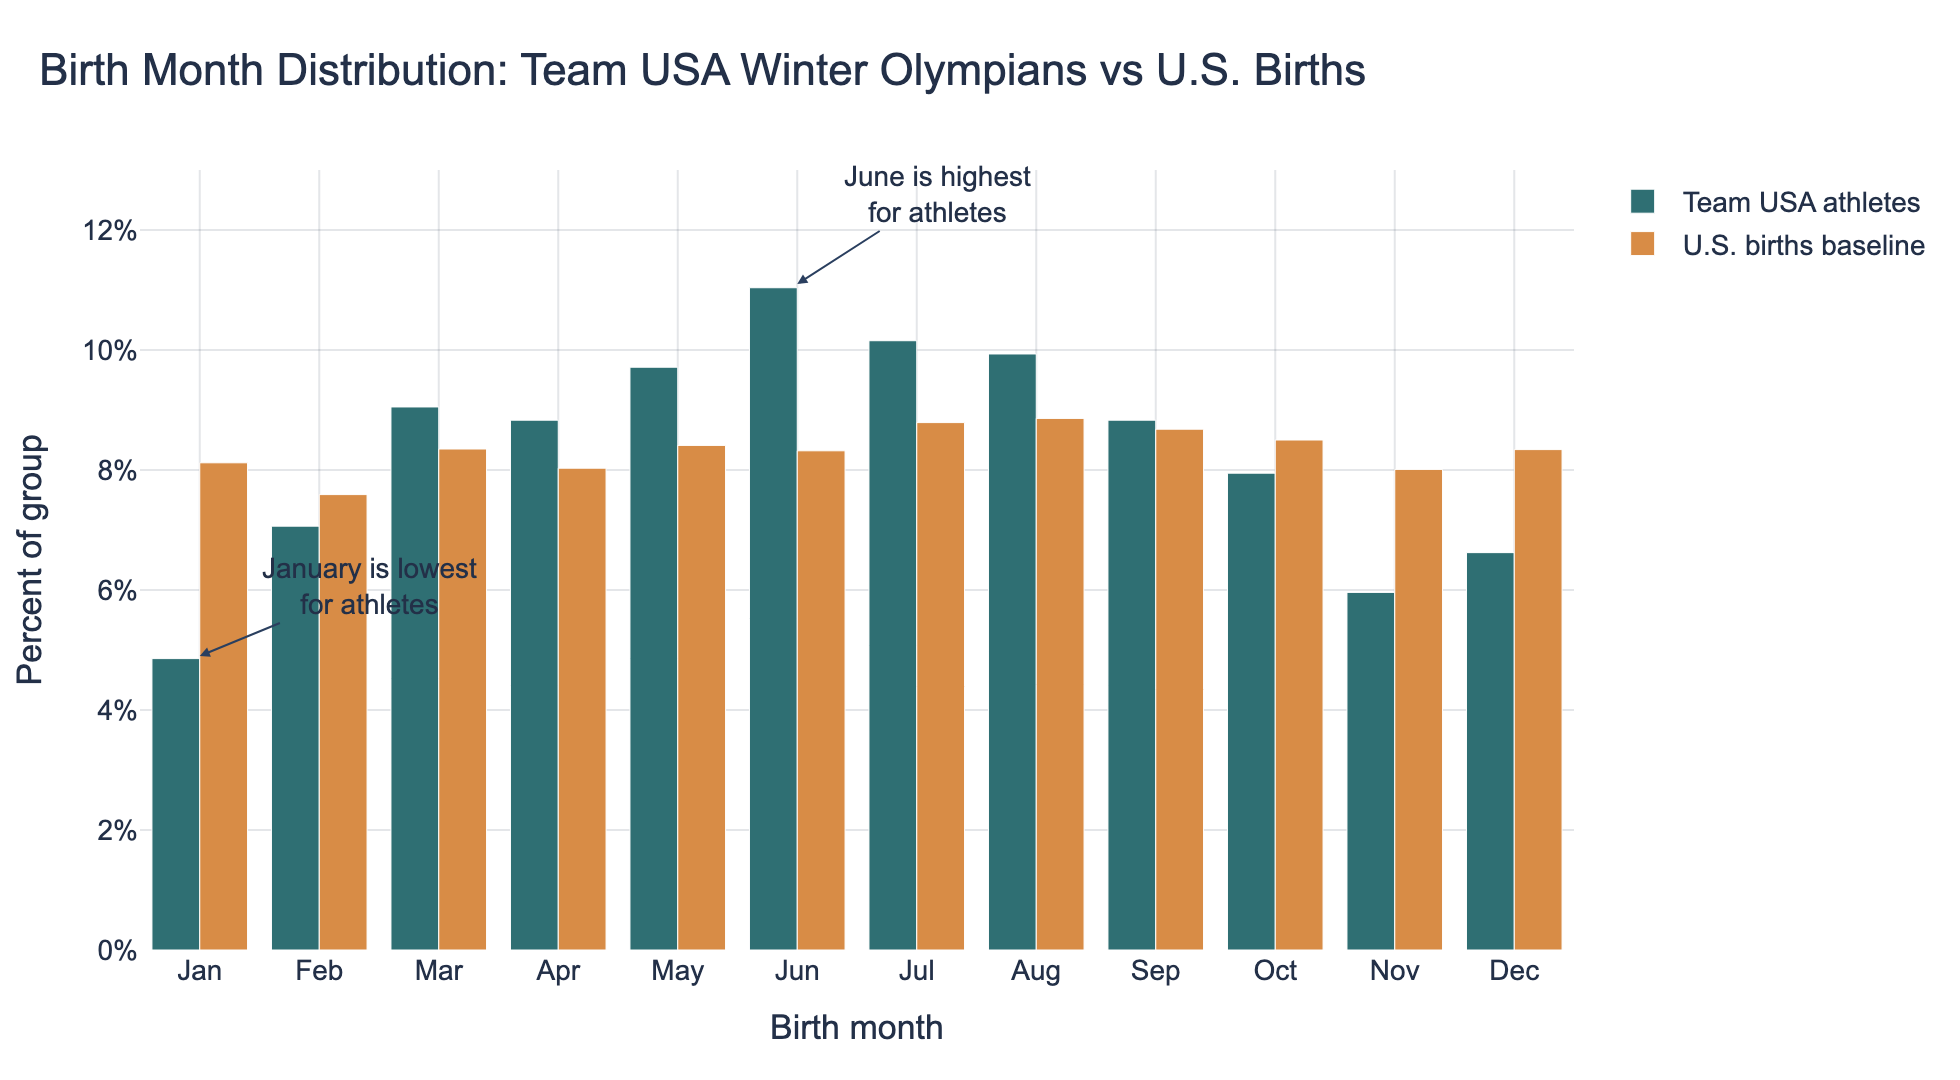

PosixPath('data/03-figures/01_birth_month_distribution_team_usa_winter_olympians_vs_u_s_births.png')

In [7]:
# Plot 1: Compare athlete birth-month percentages against U.S. birth timing.
# This directly tests whether athlete birthdays are evenly distributed relative to the population baseline.
month_long = month_dist[['month_label', 'athlete_percent', 'percent_births']].melt(
    id_vars='month_label',
    value_vars=['athlete_percent', 'percent_births'],
    var_name='group',
    value_name='percent',
)
month_long['group'] = month_long['group'].map({
    'athlete_percent': 'Team USA athletes',
    'percent_births': 'U.S. births baseline',
})
fig = px.bar(
    month_long,
    x='month_label',
    y='percent',
    color='group',
    barmode='group',
    category_orders={'month_label': MONTH_LABELS},
    color_discrete_map={'Team USA athletes': COLORS['athletes'], 'U.S. births baseline': COLORS['us']},
    labels={'month_label': 'Birth month', 'percent': 'Percent of group'},
)
fig.update_traces(cliponaxis=False)
fig.update_yaxes(range=[0, 13], ticksuffix='%')
fig.add_annotation(x='Jun', y=11.1, text='June is highest<br>for athletes', showarrow=True, arrowhead=2, ax=70, ay=-45)
fig.add_annotation(x='Jan', y=4.9, text='January is lowest<br>for athletes', showarrow=True, arrowhead=2, ax=85, ay=-35)
save_and_show_plot(fig, 'Birth Month Distribution: Team USA Winter Olympians vs U.S. Births', width=980, height=540)

Saved static PNG to data/03-figures/02_birth_quarter_distribution.png


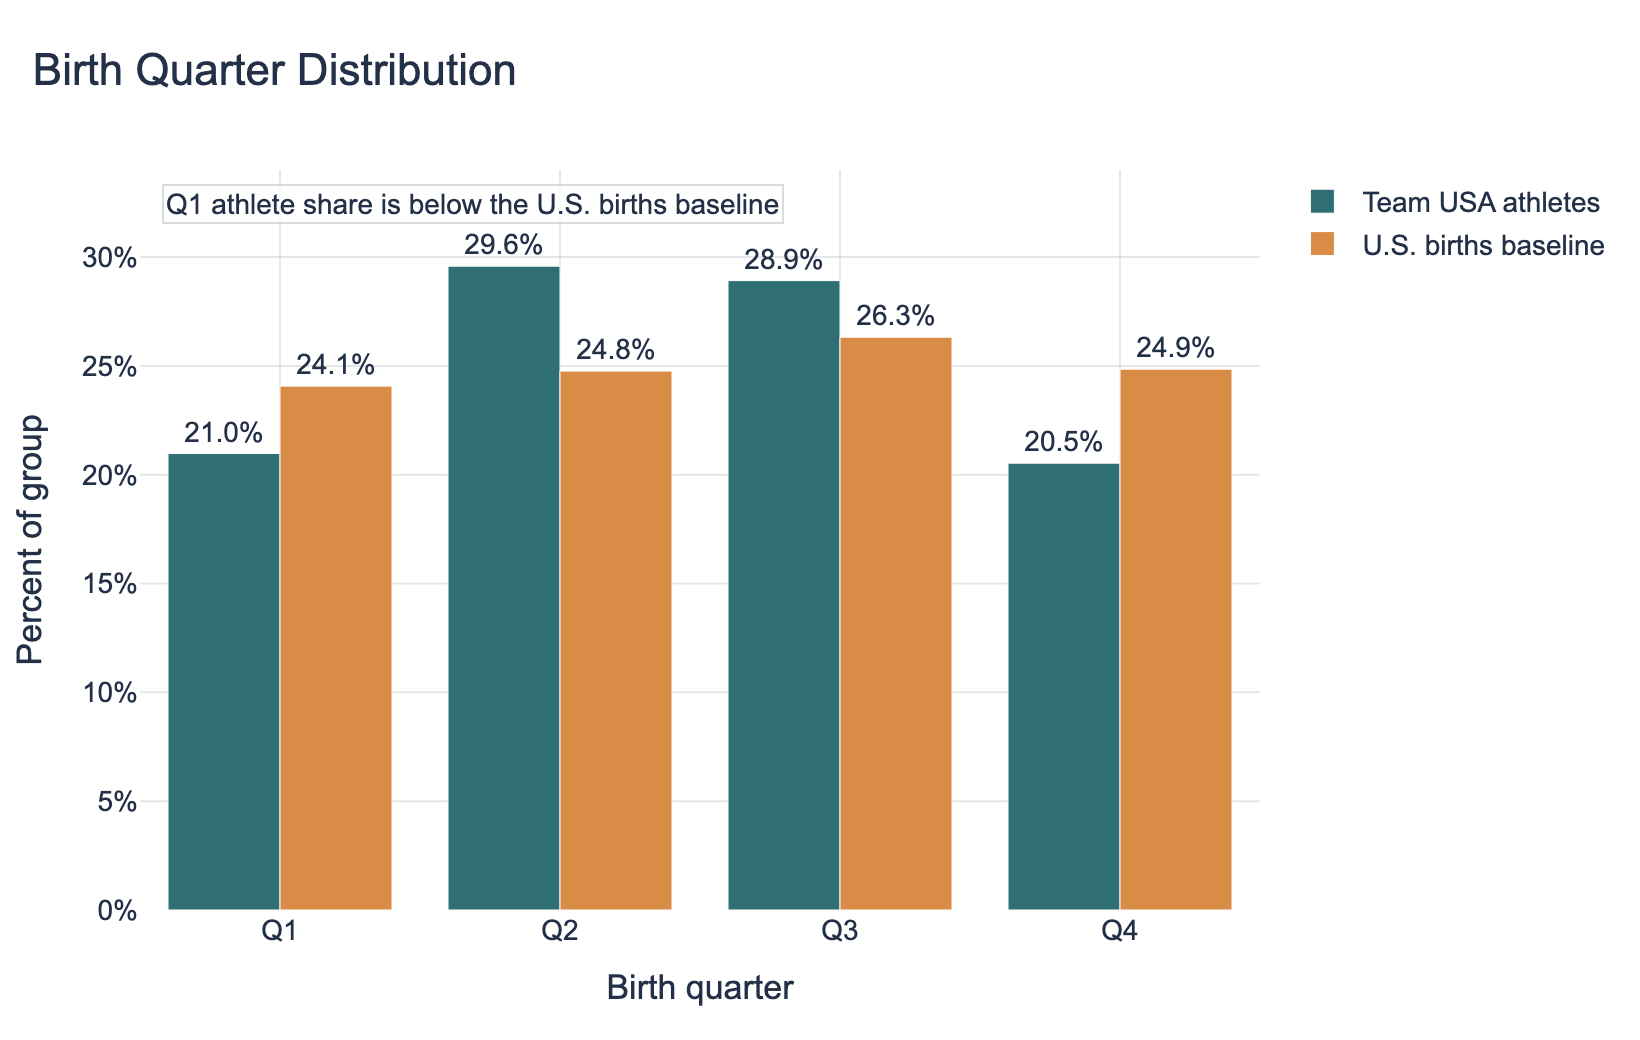

PosixPath('data/03-figures/02_birth_quarter_distribution.png')

In [8]:
# Plot 2: Collapse months into quarters to align with the relative-age-effect hypothesis.
# The quarter view reduces month-to-month noise and makes Q1/Q4 comparisons easier to read.
quarter_long = quarter_dist[['quarter_label', 'athlete_percent', 'percent_births']].melt(
    id_vars='quarter_label',
    value_vars=['athlete_percent', 'percent_births'],
    var_name='group',
    value_name='percent',
)
quarter_long['group'] = quarter_long['group'].map({
    'athlete_percent': 'Team USA athletes',
    'percent_births': 'U.S. births baseline',
})
fig = px.bar(
    quarter_long,
    x='quarter_label',
    y='percent',
    color='group',
    barmode='group',
    category_orders={'quarter_label': QUARTER_LABELS},
    color_discrete_map={'Team USA athletes': COLORS['athletes'], 'U.S. births baseline': COLORS['us']},
    labels={'quarter_label': 'Birth quarter', 'percent': 'Percent of group'},
    text=quarter_long['percent'].map(lambda value: f'{value:.1f}%'),
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_yaxes(range=[0, 34], ticksuffix='%')
fig.add_annotation(
    x=0.02,
    y=0.98,
    xref='paper',
    yref='paper',
    text='Q1 athlete share is below the U.S. births baseline',
    showarrow=False,
    align='left',
    bgcolor='rgba(255,255,255,0.85)',
    bordercolor='rgba(104,112,118,0.25)',
    borderwidth=1,
)
save_and_show_plot(fig, 'Birth Quarter Distribution', width=820, height=520)

Saved static PNG to data/03-figures/03_age_distribution_at_opening_ceremony.png


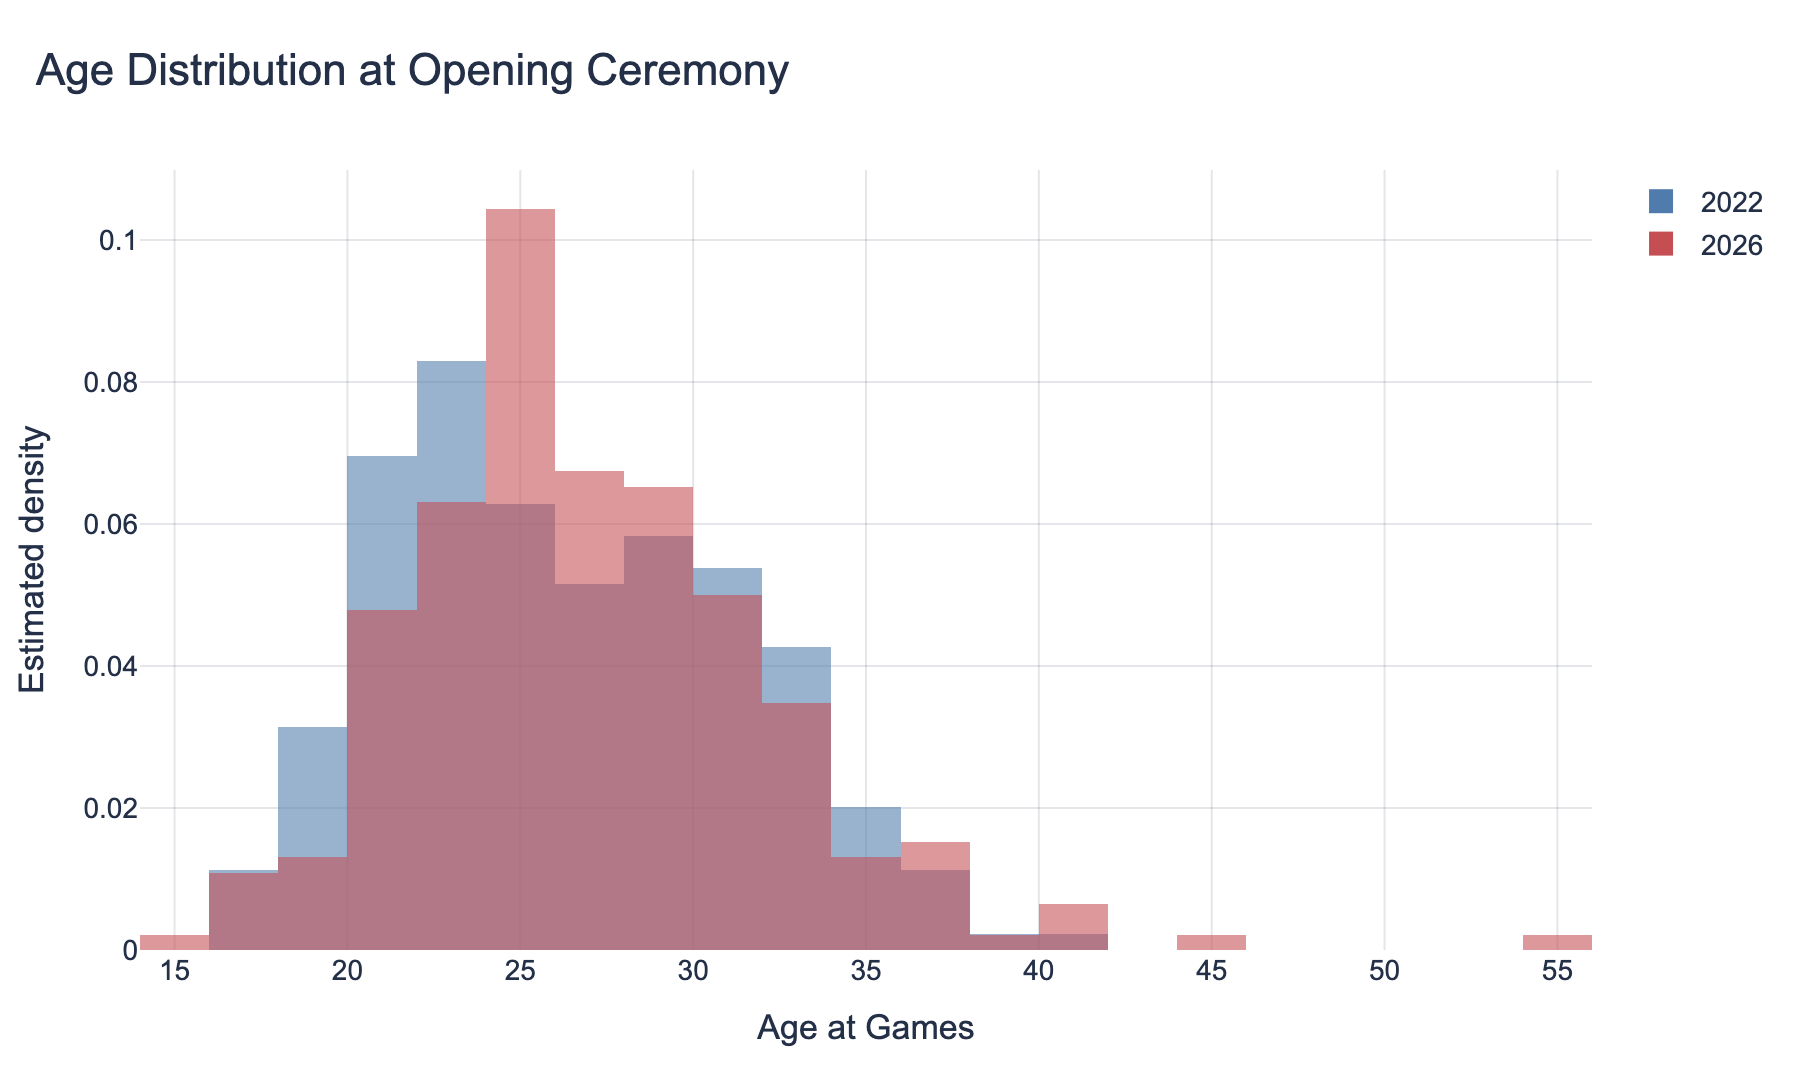

PosixPath('data/03-figures/03_age_distribution_at_opening_ceremony.png')

In [9]:
# Plot 3: Check the age distribution at the opening ceremony for each Games year.
# Age matters because cohort mix could confound apparent birth-month or birth-quarter patterns.
fig = px.histogram(
    athletes,
    x='age_at_games',
    color='games_year',
    nbins=28,
    histnorm='probability density',
    barmode='overlay',
    opacity=0.58,
    color_discrete_sequence=[COLORS['opening_2022'], COLORS['opening_2026']],
    labels={'age_at_games': 'Age at Games', 'games_year': 'Games year'},
)
fig.update_layout(legend_title_text='Games year')
fig.update_yaxes(title='Estimated density')
save_and_show_plot(fig, 'Age Distribution at Opening Ceremony', width=900, height=540)

Saved static PNG to data/03-figures/04_athlete_count_by_sport.png


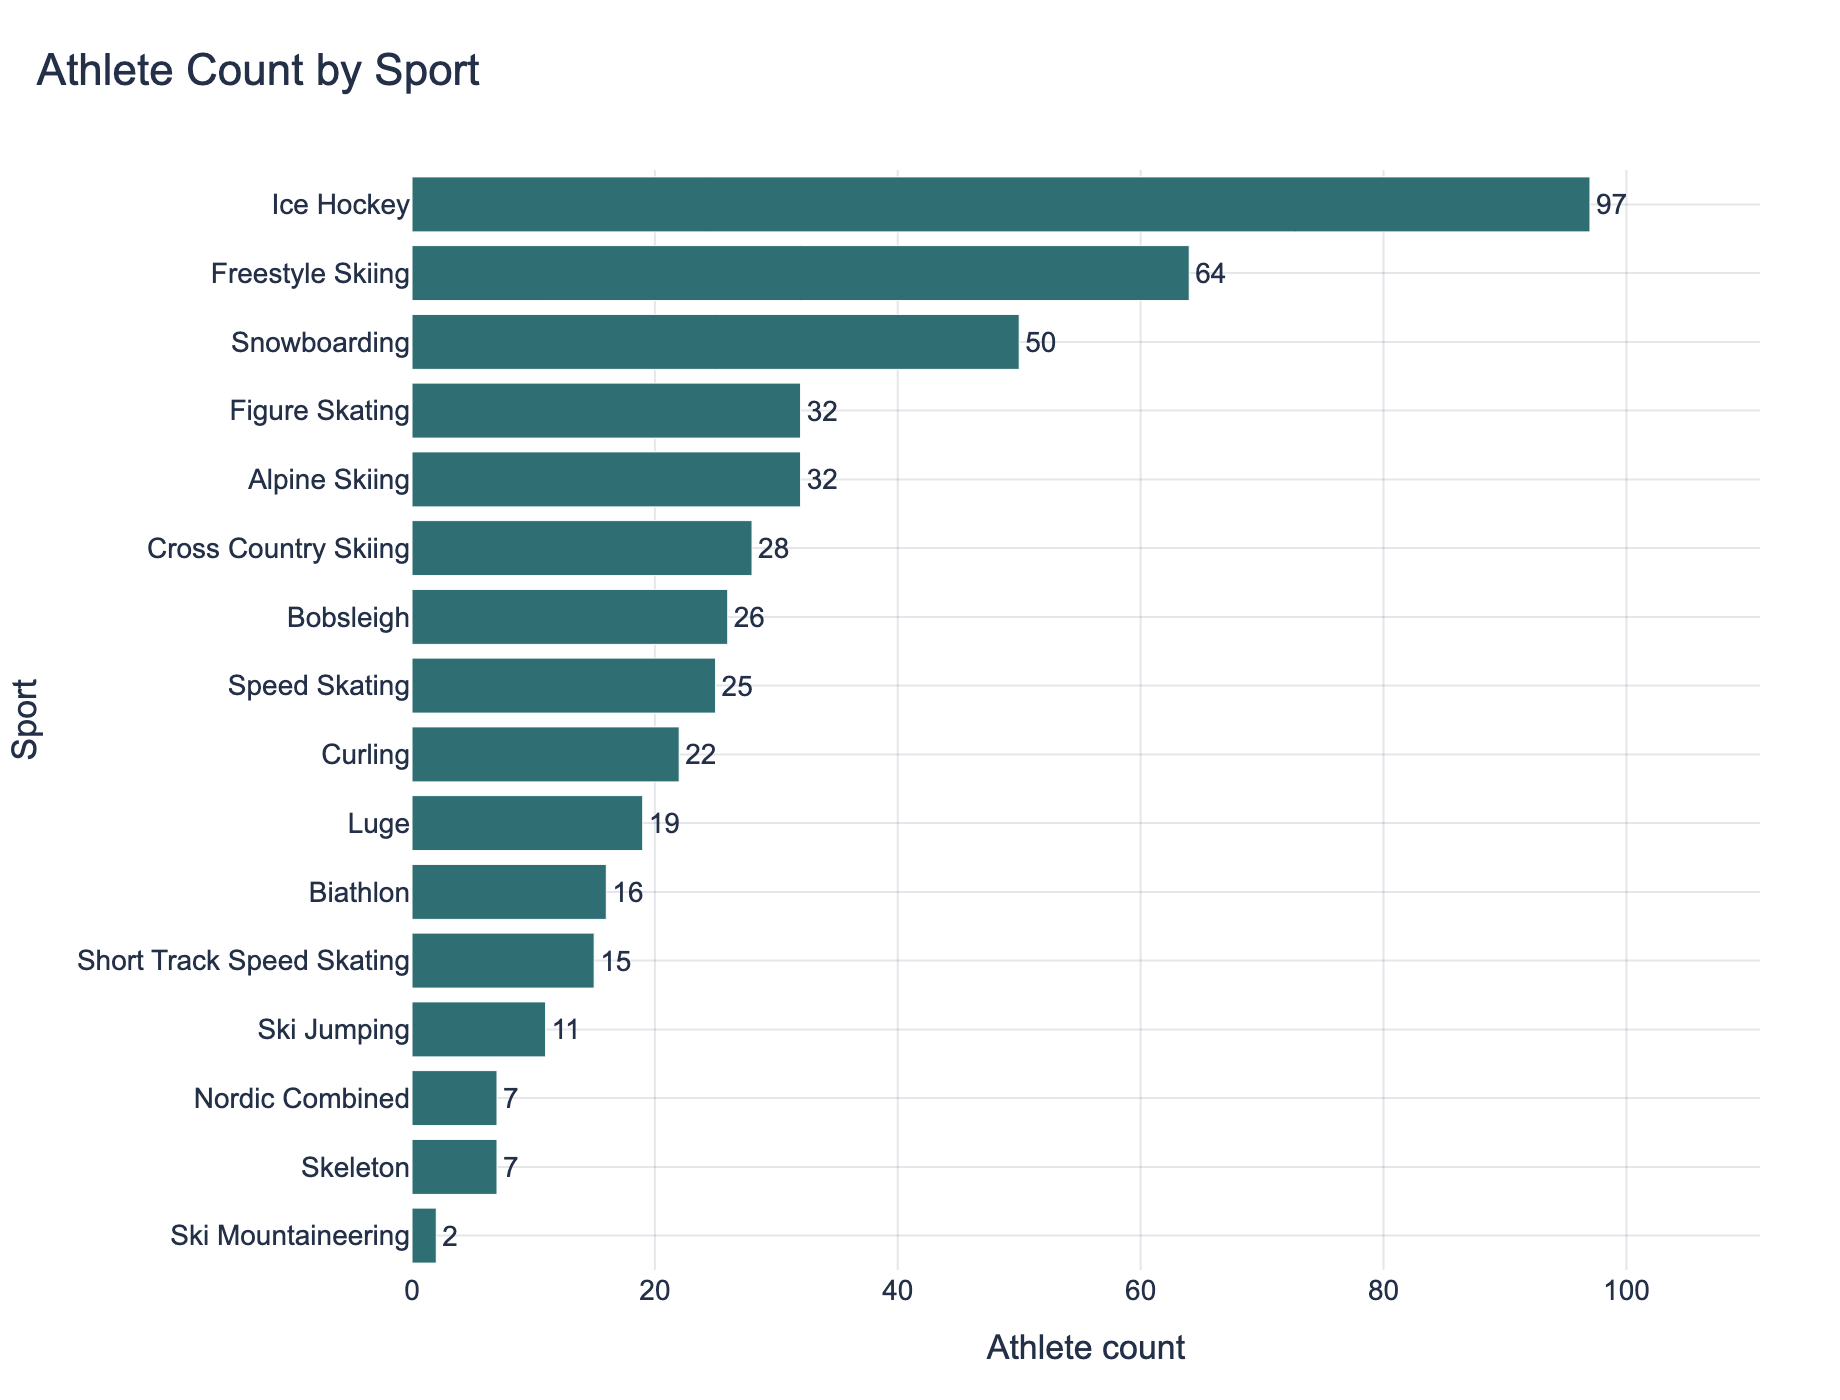

PosixPath('data/03-figures/04_athlete_count_by_sport.png')

In [10]:
# Plot 4: Show sport composition after the cleaning fix that fills missing sport labels.
# This is a useful sanity check because the original scraping issue inflated a fake sport category.
fig = px.bar(
    sports,
    x='athlete_count',
    y='sport',
    orientation='h',
    text='athlete_count',
    color_discrete_sequence=[COLORS['athletes']],
    labels={'athlete_count': 'Athlete count', 'sport': 'Sport'},
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_xaxes(range=[0, sports['athlete_count'].max() + 14])
save_and_show_plot(fig, 'Athlete Count by Sport', width=920, height=700)

##### Are there any outliers?

In [11]:
outlier_checks = pd.DataFrame({
    'check': [
        'rows',
        'missing birth_month',
        'missing birth_quarter',
        'missing sports',
        'duplicate athlete-Games rows',
        'youngest age_at_games',
        'oldest age_at_games',
    ],
    'value': [
        len(athletes),
        athletes['birth_month'].isna().sum(),
        athletes['birth_quarter'].isna().sum(),
        (athletes['sports'].isna() | (athletes['sports'].astype(str).str.strip() == '')).sum(),
        athletes.duplicated(subset=['id', 'games_year']).sum(),
        athletes['age_at_games'].min(),
        athletes['age_at_games'].max(),
    ],
})
display(outlier_checks)

age_extremes = athletes.sort_values('age_at_games').head(5)[['name', 'games_year', 'age_at_games', 'sports', 'birth_month']]
age_extremes = pd.concat([
    age_extremes,
    athletes.sort_values('age_at_games', ascending=False).head(5)[['name', 'games_year', 'age_at_games', 'sports', 'birth_month']],
])
print('Youngest and oldest athlete-Games appearances:')
display(age_extremes)

print('Months with the largest observed-minus-expected differences:')
display(month_dist.sort_values('count_difference')[['month_label', 'athlete_count', 'expected_count', 'count_difference']].round(2))

,check,value
0,rows,453.00
1,missing birth_month,0.00
2,missing birth_quarter,0.00
3,missing sports,0.00
4,duplicate athlete-Games rows,0.00
5,youngest age_at_games,15.77
6,oldest age_at_games,54.86


Youngest and oldest athlete-Games appearances:


,name,games_year,age_at_games,sports,birth_month
225,Abby Winterberger,2026,15.77,Freestyle Skiing,5
344,Jess Perlmutter,2026,16.18,Snowboarding,12
378,Lily Dhawornvej,2026,16.48,Snowboarding,8
12,Alysa Liu,2022,16.49,Figure Skating,8
75,Eunice Lee,2022,17.23,Short Track Speed Skating,11
417,Rich Ruohonen,2026,54.86,Curling,3
401,Nick Baumgartner,2026,44.14,Snowboarding,12
294,Elana Meyers Taylor,2026,41.33,Bobsleigh,10
379,Lindsey Vonn,2026,41.30,Alpine Skiing,10
356,Kaillie Humphries,2026,40.42,Bobsleigh,9


Months with the largest observed-minus-expected differences:


,month_label,athlete_count,expected_count,count_difference
0,Jan,22,36.78,-14.78
10,Nov,27,36.29,-9.29
11,Dec,30,37.78,-7.78
9,Oct,36,38.51,-2.51
1,Feb,32,34.38,-2.38
8,Sep,40,39.32,0.68
2,Mar,41,37.83,3.17
3,Apr,40,36.38,3.62
7,Aug,45,40.14,4.86
4,May,44,38.10,5.90


Saved static PNG to data/03-figures/05_observed_athlete_counts_minus_expected_counts_by_month.png


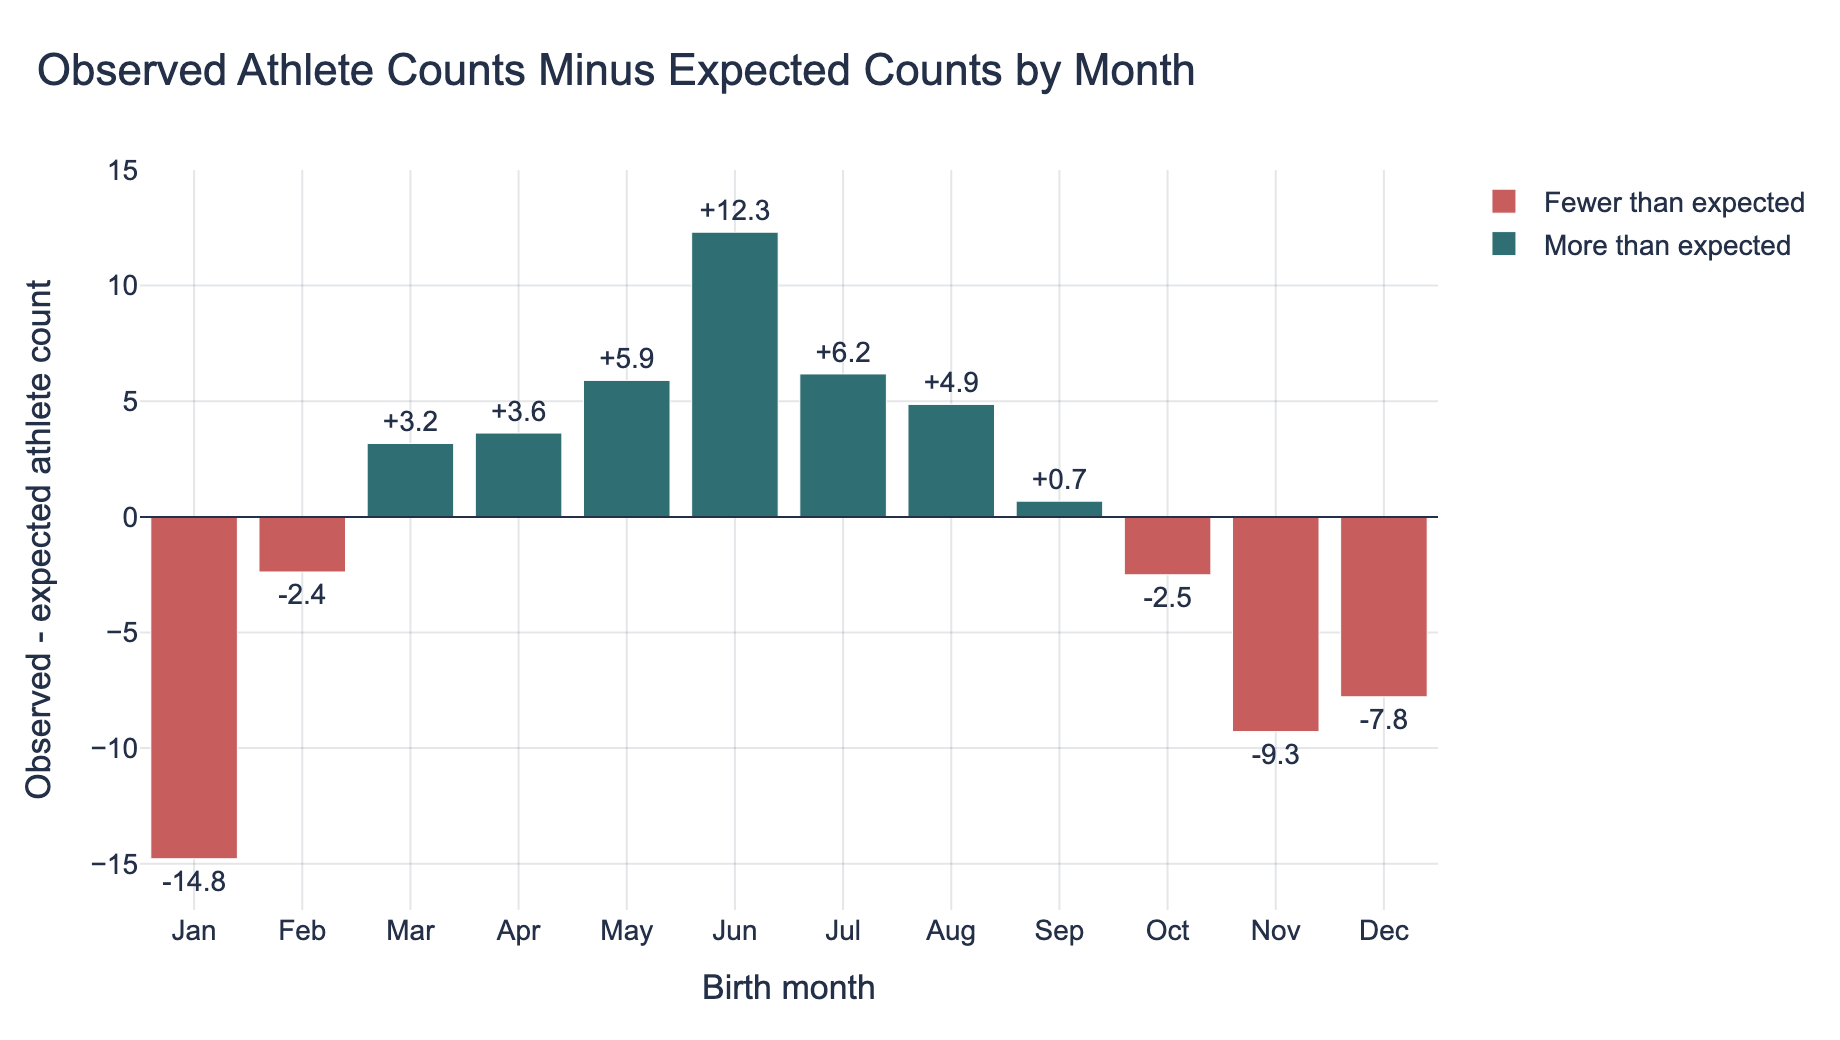

PosixPath('data/03-figures/05_observed_athlete_counts_minus_expected_counts_by_month.png')

In [12]:
# Plot 5: Translate percentages into athlete counts above or below expectation.
# Positive bars mean more athletes were born in that month than expected from U.S. births; negative bars mean fewer.
diff_frame = month_dist.copy()
diff_frame['direction'] = np.where(diff_frame['count_difference'] >= 0, 'More than expected', 'Fewer than expected')
fig = px.bar(
    diff_frame,
    x='month_label',
    y='count_difference',
    color='direction',
    category_orders={'month_label': MONTH_LABELS},
    color_discrete_map={'More than expected': COLORS['positive'], 'Fewer than expected': COLORS['negative']},
    labels={'month_label': 'Birth month', 'count_difference': 'Observed - expected athlete count'},
    text=diff_frame['count_difference'].map(lambda value: f'{value:+.1f}'),
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.add_hline(y=0, line_color='#233048', line_width=1)
fig.update_yaxes(range=[-17, 15])
save_and_show_plot(fig, 'Observed Athlete Counts Minus Expected Counts by Month', width=920, height=520)

Saved static PNG to data/03-figures/06_age_outliers_by_birth_quarter.png


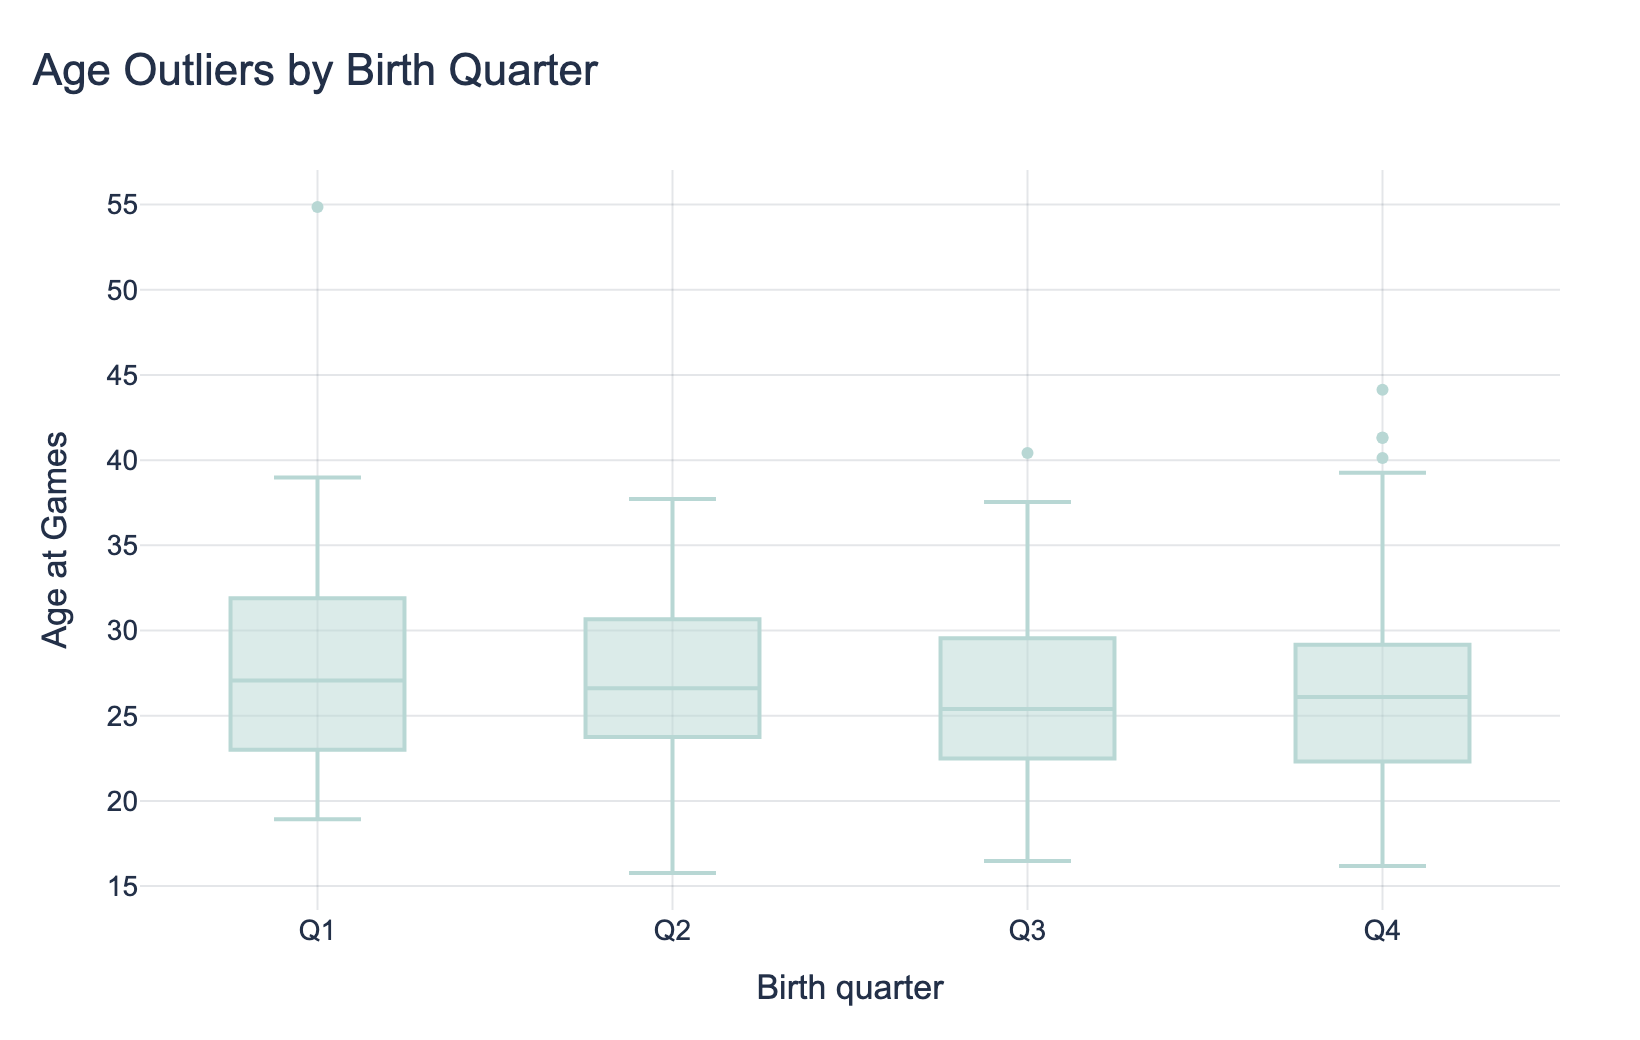

PosixPath('data/03-figures/06_age_outliers_by_birth_quarter.png')

In [13]:
# Plot 6: Use box plots to identify age outliers within each birth quarter.
# This checks whether one quarter's pattern is driven by unusually old or young athlete appearances.
fig = px.box(
    athletes,
    x='quarter_label',
    y='age_at_games',
    points='outliers',
    category_orders={'quarter_label': QUARTER_LABELS},
    color_discrete_sequence=['#b8d7d4'],
    labels={'quarter_label': 'Birth quarter', 'age_at_games': 'Age at Games'},
)
save_and_show_plot(fig, 'Age Outliers by Birth Quarter', width=820, height=520)

Saved static PNG to data/03-figures/07_age_distribution_shape_by_birth_quarter.png


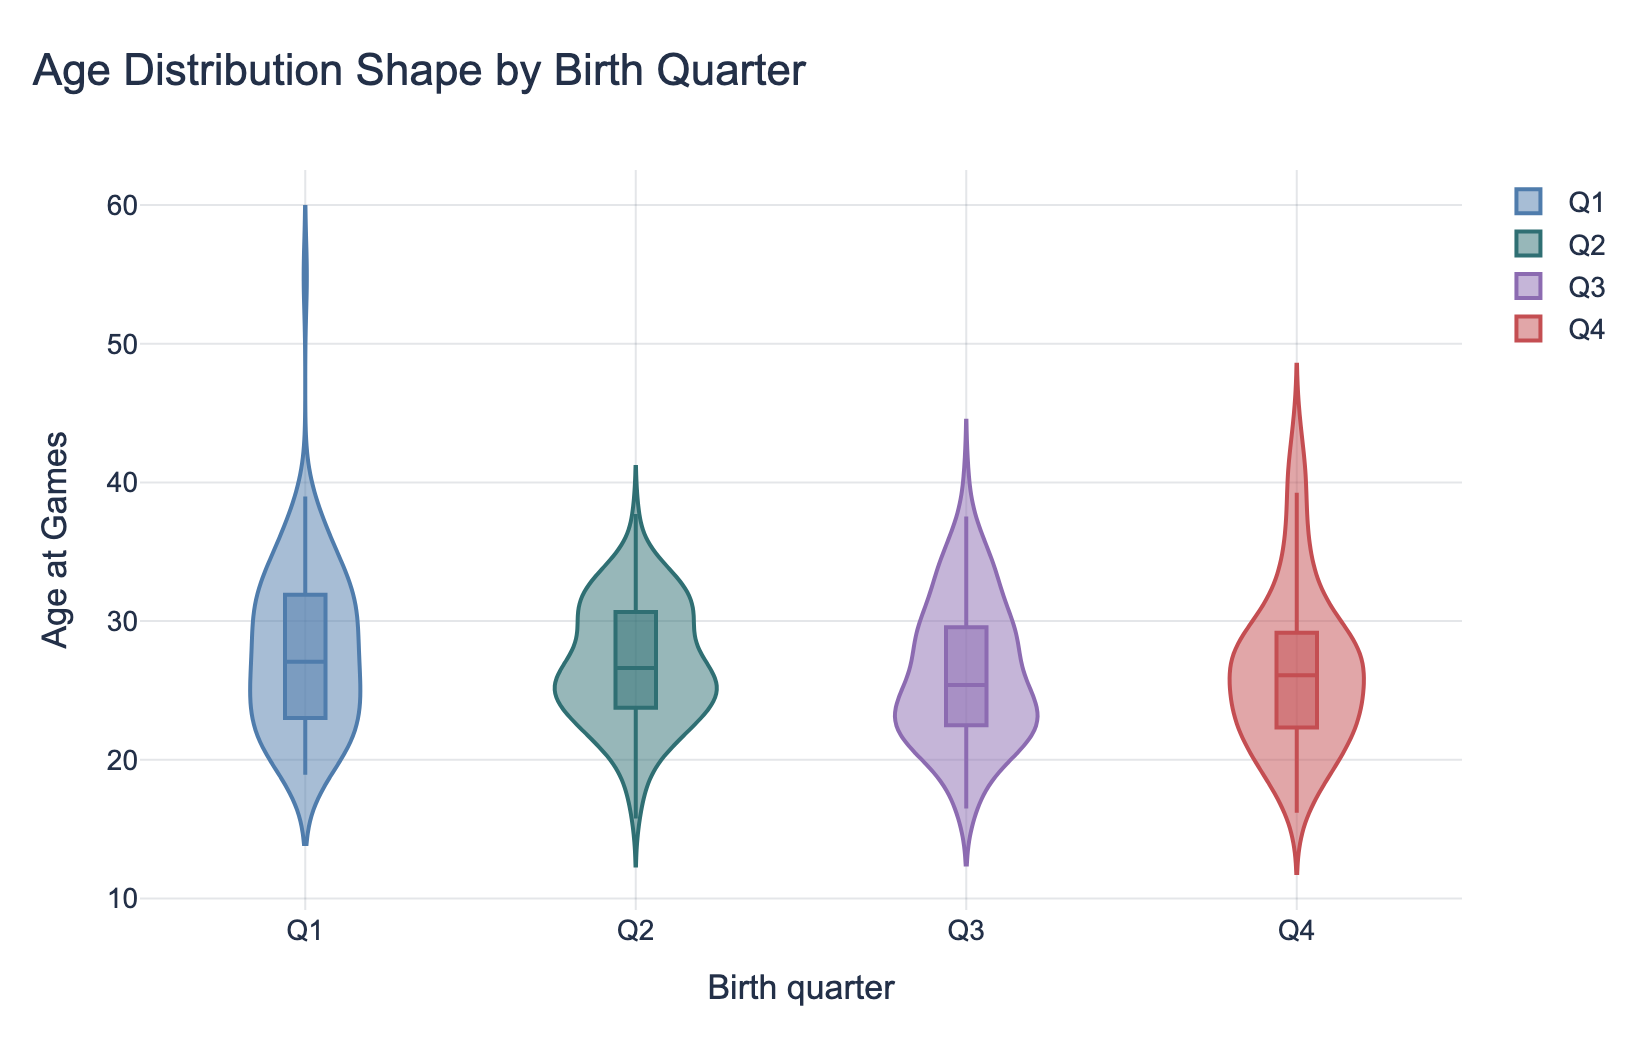

PosixPath('data/03-figures/07_age_distribution_shape_by_birth_quarter.png')

In [14]:
# Plot 7: Violin plots show the full age distribution shape by quarter, not just medians and outliers.
# This complements the box plot by revealing whether age is concentrated or spread out within each quarter.
fig = px.violin(
    athletes,
    x='quarter_label',
    y='age_at_games',
    color='quarter_label',
    box=True,
    points=False,
    category_orders={'quarter_label': QUARTER_LABELS},
    color_discrete_map=QUARTER_COLORS,
    labels={'quarter_label': 'Birth quarter', 'age_at_games': 'Age at Games'},
)
save_and_show_plot(fig, 'Age Distribution Shape by Birth Quarter', width=820, height=520)

##### Relationship between variables

Saved static PNG to data/03-figures/08_sport_by_birth_quarter_heatmap.png


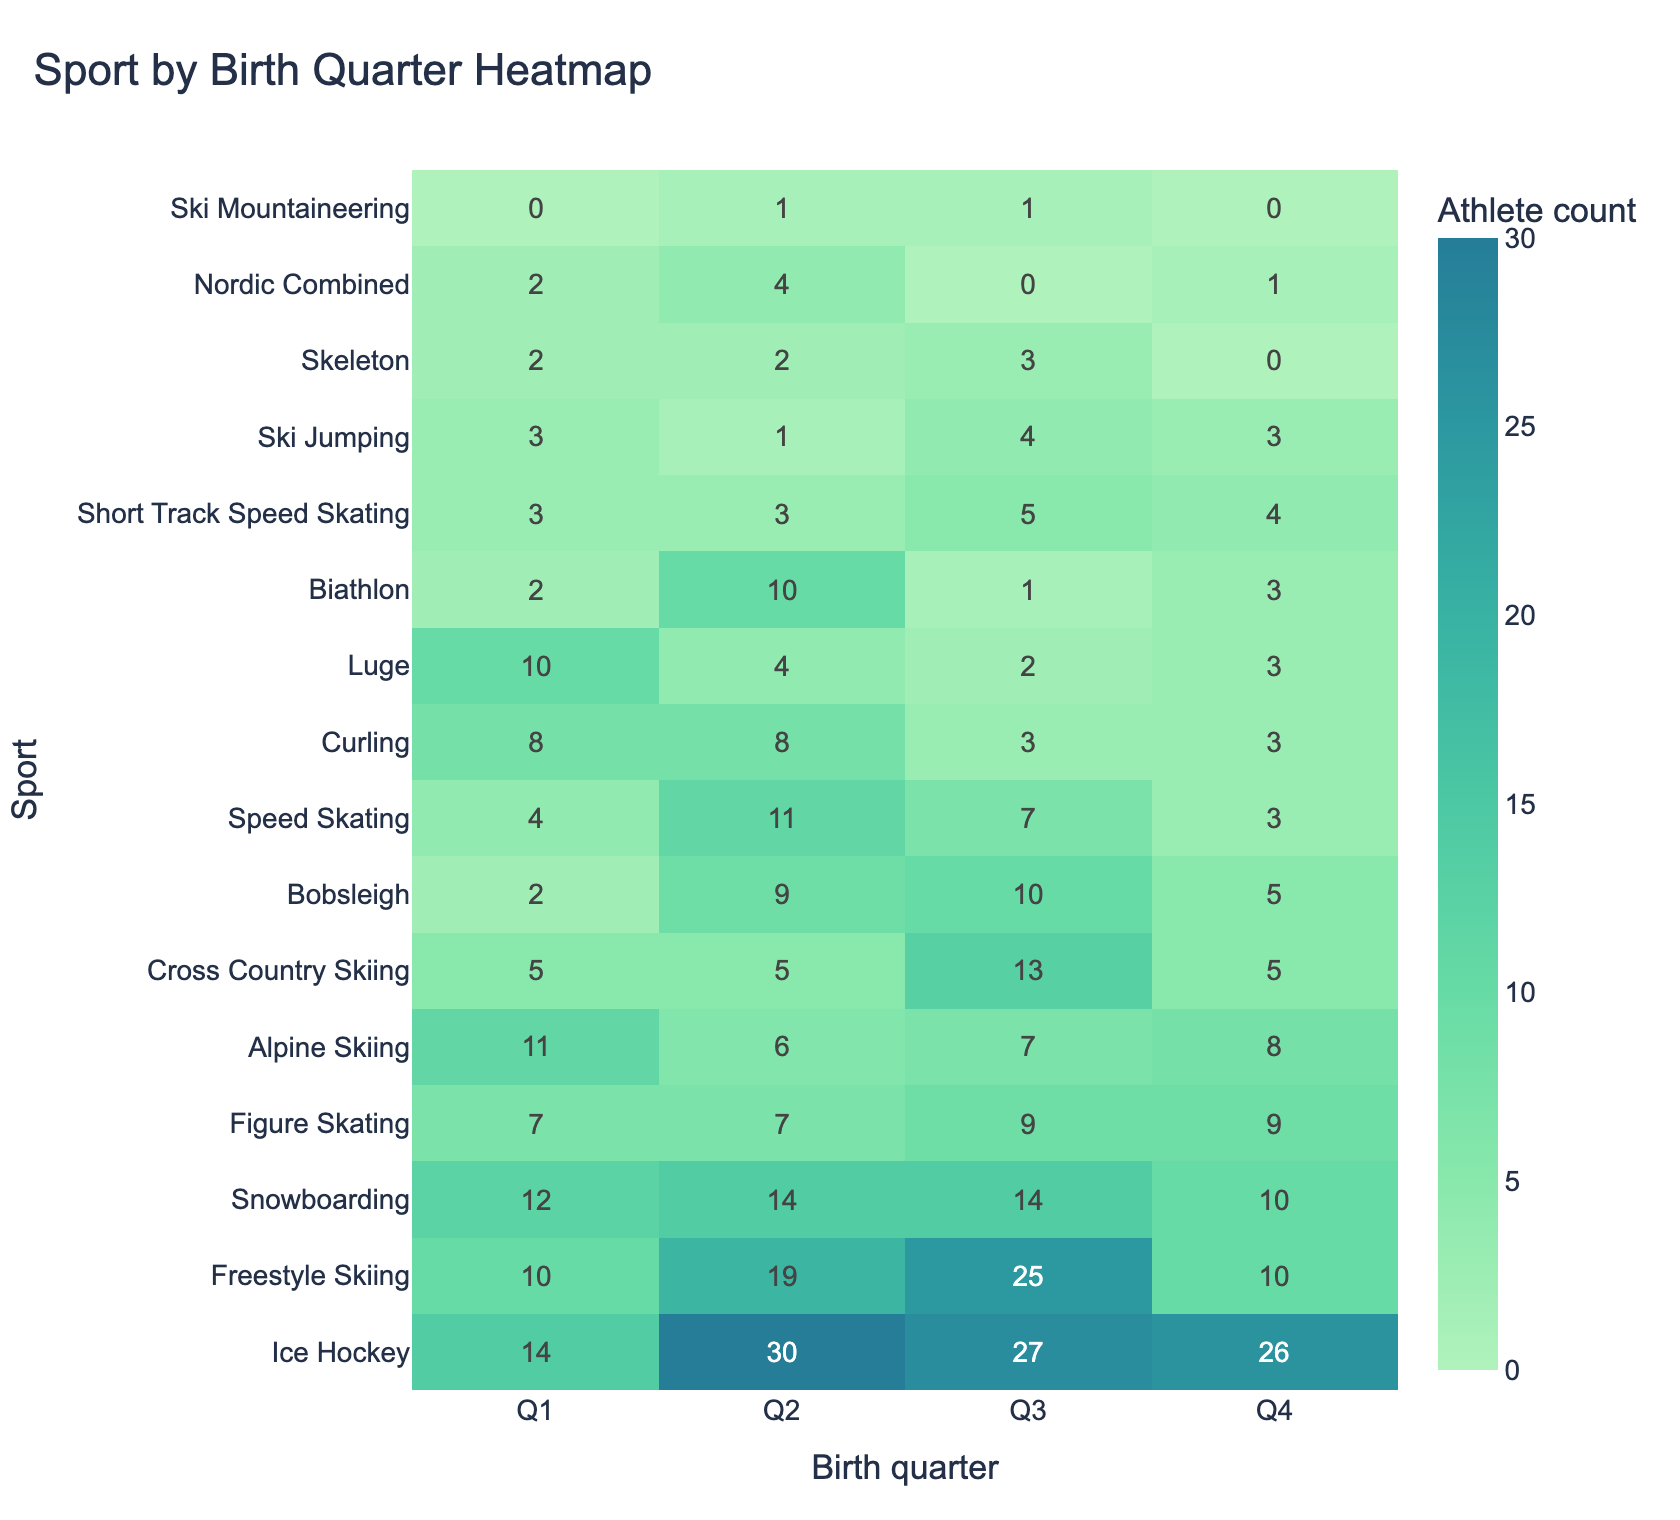

PosixPath('data/03-figures/08_sport_by_birth_quarter_heatmap.png')

In [15]:
# Plot 8: Cross-tabulate sport and birth quarter to see whether quarter patterns vary by sport.
# Counts are shown directly in the heatmap so small sports remain interpretable.
sport_quarter_pivot = (
    sport_quarter.pivot(index='sports', columns='quarter_label', values='athlete_count')
    .reindex(columns=QUARTER_LABELS)
    .fillna(0)
)
sport_quarter_pivot = sport_quarter_pivot.loc[sport_quarter_pivot.sum(axis=1).sort_values(ascending=True).index]
fig = px.imshow(
    sport_quarter_pivot,
    text_auto='.0f',
    aspect='auto',
    color_continuous_scale='Tealgrn',
    labels={'x': 'Birth quarter', 'y': 'Sport', 'color': 'Athlete count'},
)
save_and_show_plot(fig, 'Sport by Birth Quarter Heatmap', width=840, height=760)

Saved static PNG to data/03-figures/09_medal_winning_share_by_birth_quarter.png


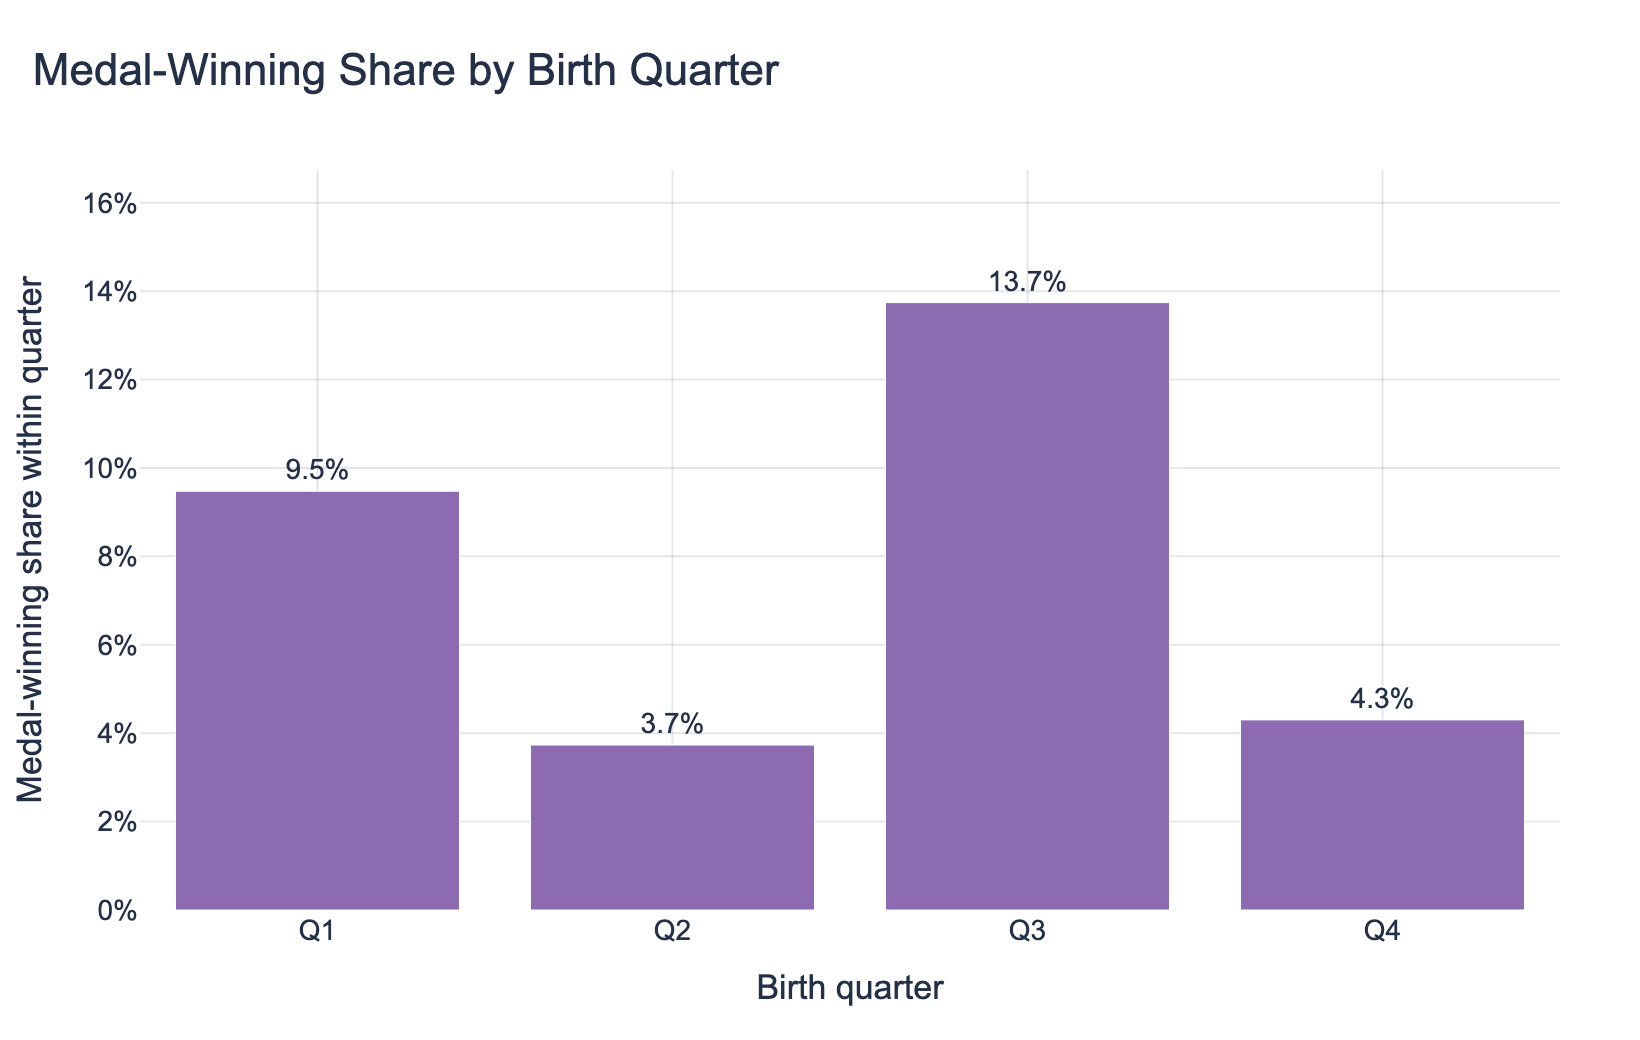

PosixPath('data/03-figures/09_medal_winning_share_by_birth_quarter.png')

In [16]:
# Plot 9: Compare medal-winning share by birth quarter as an exploratory outcome check.
# This is not a causal claim; it simply checks whether quarter composition appears related to medal outcomes.
medal_share = medal_quarter[medal_quarter['medal_status'] == 'Won medal'].copy()
medal_share['quarter_label'] = pd.Categorical(medal_share['quarter_label'], categories=QUARTER_LABELS, ordered=True)
medal_share = medal_share.sort_values('quarter_label')
fig = px.bar(
    medal_share,
    x='quarter_label',
    y='percent_within_quarter',
    category_orders={'quarter_label': QUARTER_LABELS},
    color_discrete_sequence=[COLORS['expected']],
    labels={'quarter_label': 'Birth quarter', 'percent_within_quarter': 'Medal-winning share within quarter'},
    text=medal_share['percent_within_quarter'].map(lambda value: f'{value:.1f}%'),
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_yaxes(range=[0, max(16, medal_share['percent_within_quarter'].max() + 3)], ticksuffix='%')
save_and_show_plot(fig, 'Medal-Winning Share by Birth Quarter', width=820, height=520)

Saved static PNG to data/03-figures/10_scatter_matrix_of_birth_timing_age_and_outcomes.png


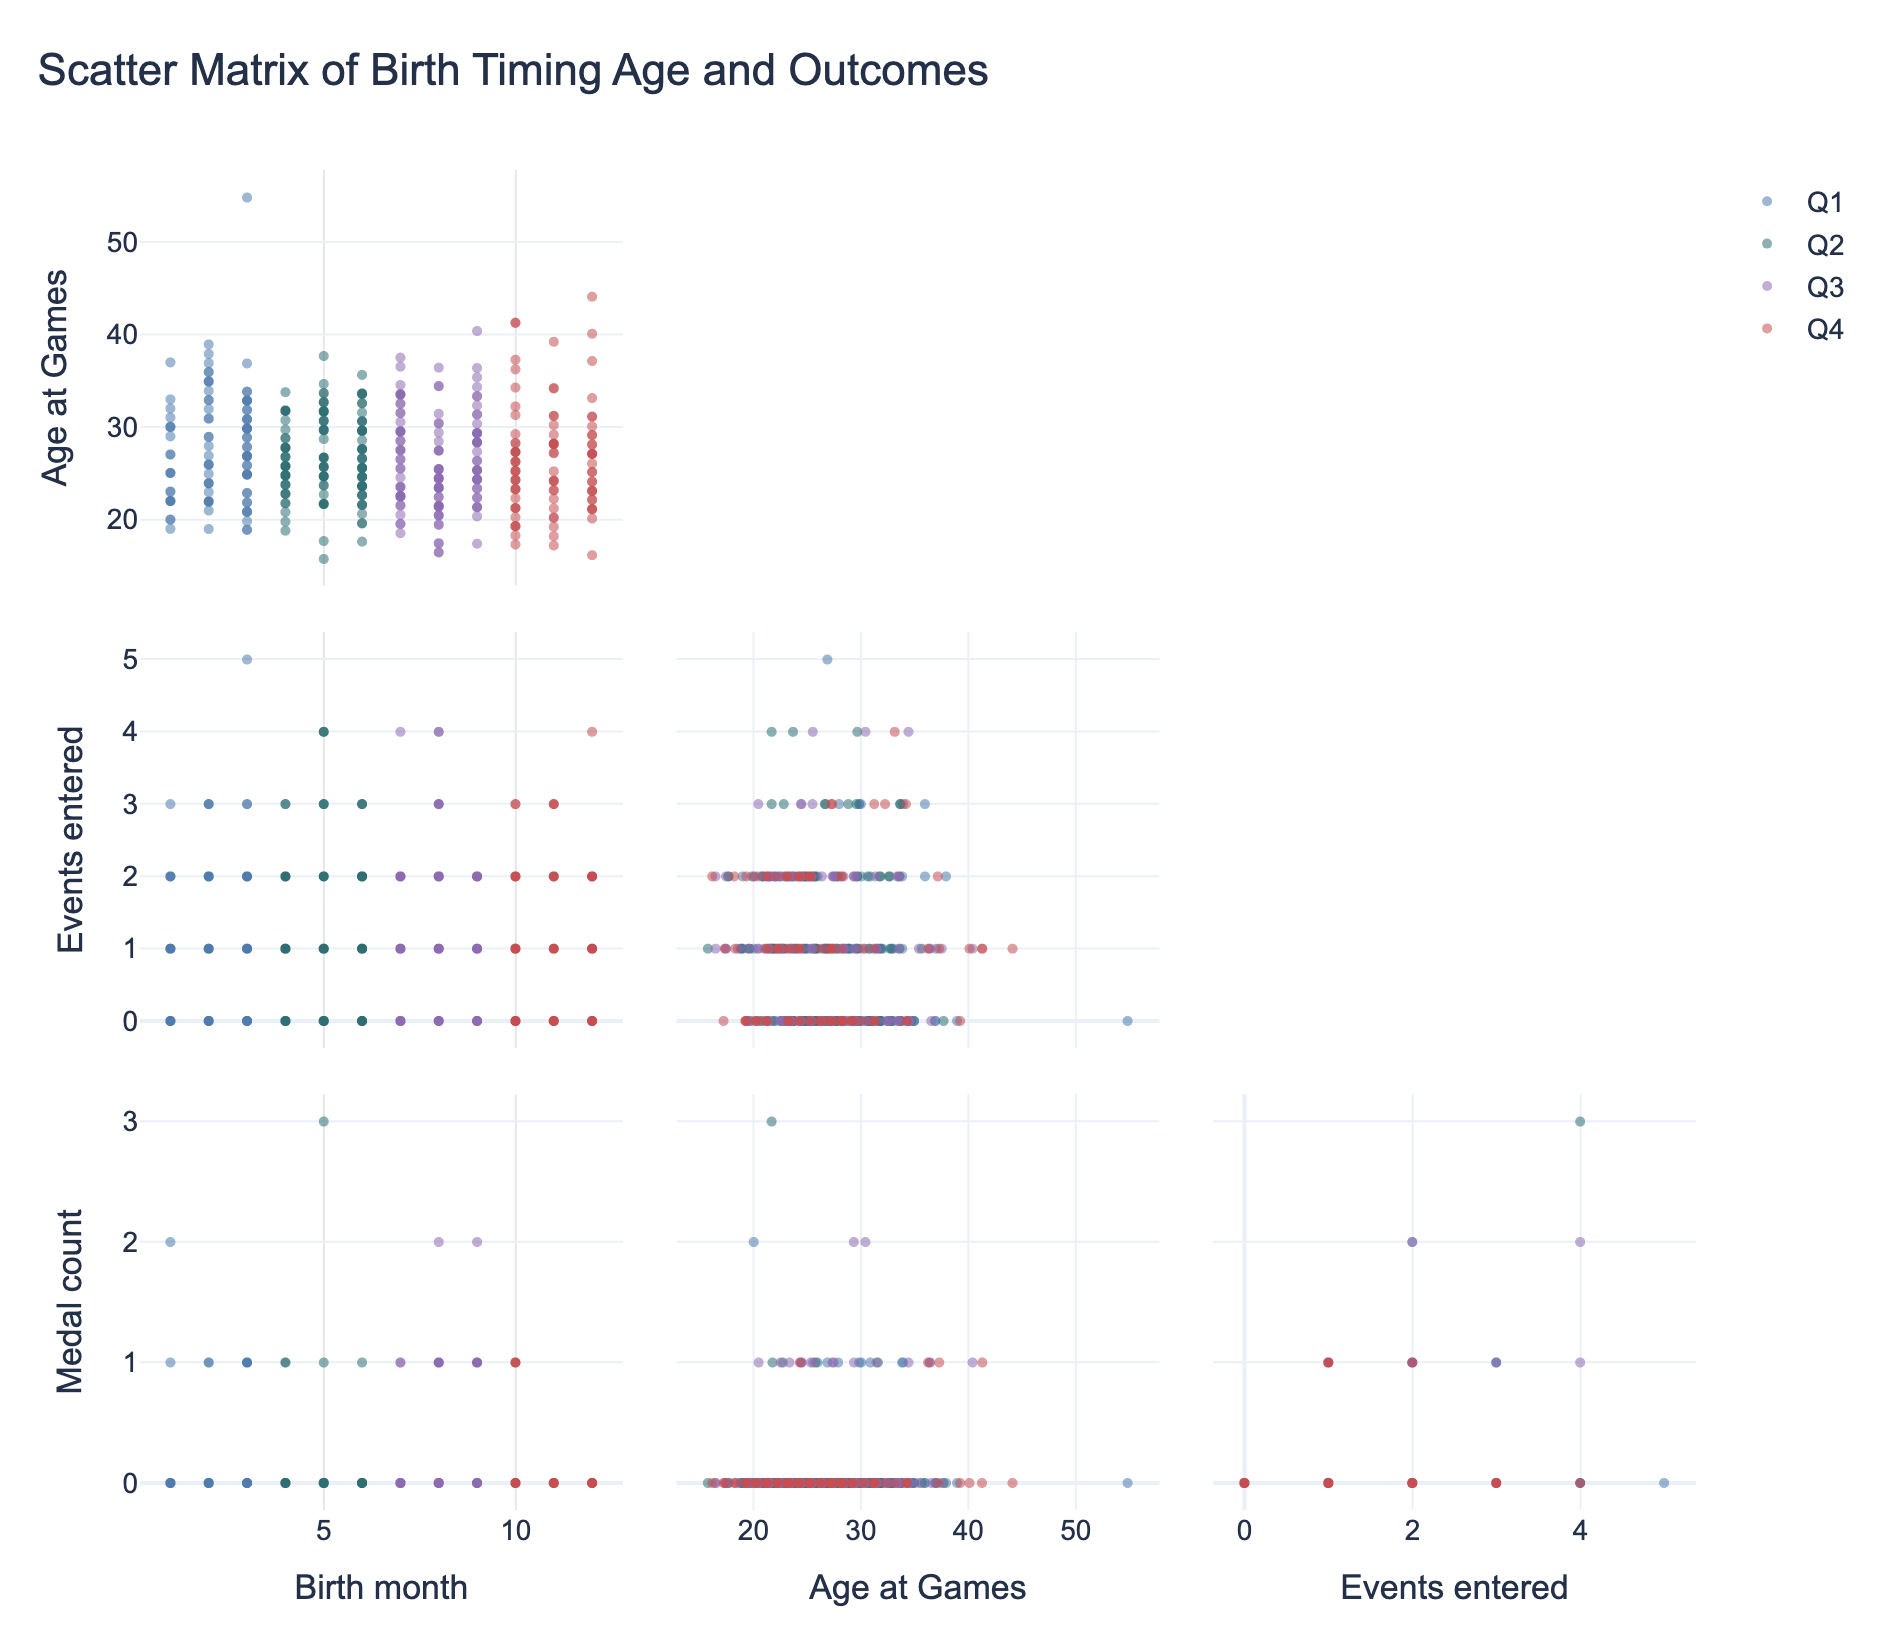

PosixPath('data/03-figures/10_scatter_matrix_of_birth_timing_age_and_outcomes.png')

In [17]:
# Plot 10: Scatter matrix gives a compact relationship scan across numeric athlete variables.
# We color by quarter to see whether birth timing separates from age, event volume, or medal count.
pair_vars = athletes[['birth_month', 'age_at_games', 'events_entered', 'medal_count', 'quarter_label']].copy()
fig = px.scatter_matrix(
    pair_vars,
    dimensions=['birth_month', 'age_at_games', 'events_entered', 'medal_count'],
    color='quarter_label',
    category_orders={'quarter_label': QUARTER_LABELS},
    color_discrete_map=QUARTER_COLORS,
    labels={
        'birth_month': 'Birth month',
        'age_at_games': 'Age at Games',
        'events_entered': 'Events entered',
        'medal_count': 'Medal count',
        'quarter_label': 'Birth quarter',
    },
)
fig.update_traces(diagonal_visible=False, showupperhalf=False, marker={'size': 5, 'opacity': 0.55})
save_and_show_plot(fig, 'Scatter Matrix of Birth Timing Age and Outcomes', width=940, height=820)

Saved static PNG to data/03-figures/11_top_u_s_birth_states_for_team_usa_winter_olympians.png


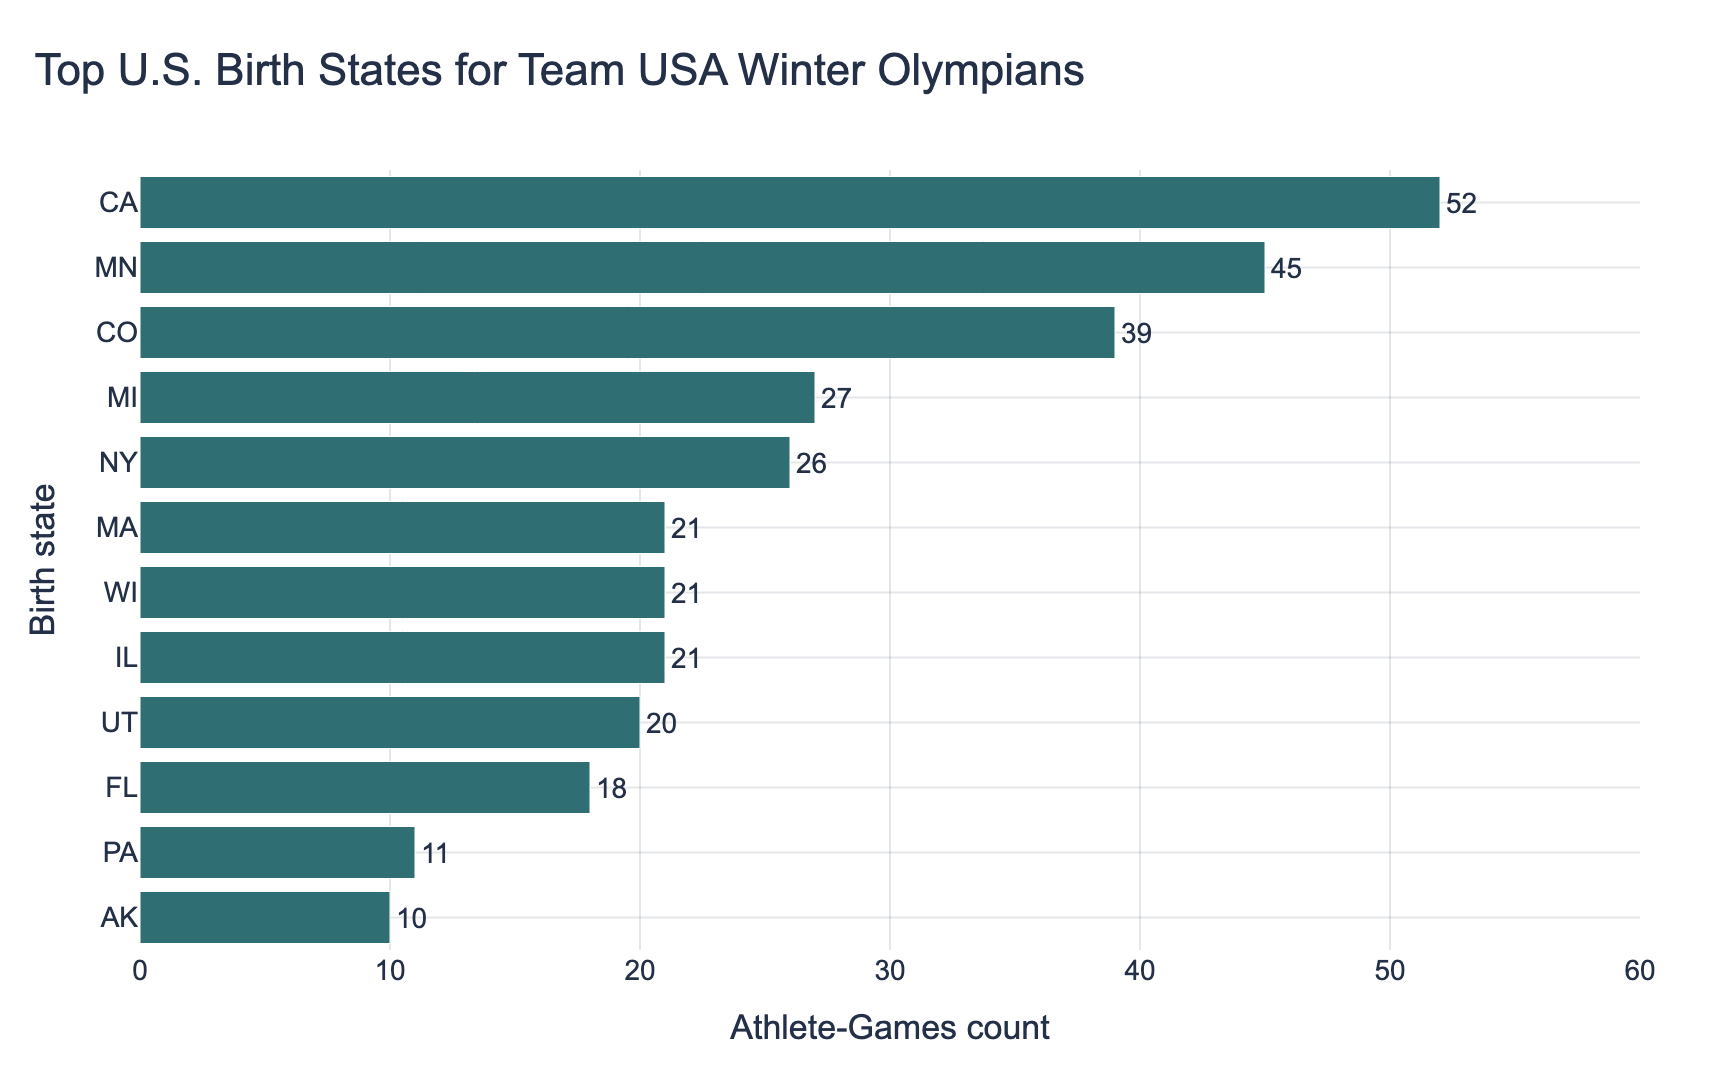

PosixPath('data/03-figures/11_top_u_s_birth_states_for_team_usa_winter_olympians.png')

In [18]:
# Plot 11: Summarize the most common U.S. birth states among Team USA Winter Olympian rows.
# This is geographic context for the athlete population, shown as a bar chart instead of an interactive map.
top_states = state_counts.head(12).sort_values('athlete_count', ascending=True)
fig = px.bar(
    top_states,
    x='athlete_count',
    y='birth_state',
    orientation='h',
    text='athlete_count',
    color_discrete_sequence=[COLORS['athletes']],
    labels={'athlete_count': 'Athlete-Games count', 'birth_state': 'Birth state'},
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_xaxes(range=[0, top_states['athlete_count'].max() + 8])
save_and_show_plot(fig, 'Top U.S. Birth States for Team USA Winter Olympians', width=860, height=540)

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: This project uses publicly available and aggregated data (Olympic athlete rosters and census data), so direct informed consent is not applicable. However, we still recognize that the data originates from real individuals and should be handled responsibly.

 - [X] **A.2 Collection bias**: There is potential bias because Olympic athletes are a highly selective group influenced by access to training, geography, and socioeconomic factors which are not related to their birth month. Additionally, comparing athlete data to the 2000 census introduces a temporal mismatch as age ranges will not be exactly the same, which may affect validity.
 - [X] **A.3 Limit PII exposure**: We only use aggregated birth month data and do not include names or exact birthdates, minimizing exposure to personally identifiable information. We will identify birth month with sport and success (medal won or score).
 - [X] **A.4 Downstream bias mitigation**: Data will be categorized as Olympian or the U.S. census collectively. As such, there will be no potential for biased outcomes in relation to protected group status such as race or gender as we are not focusing on that information.

### B. Data Storage
 - [X] **B.1 Data security**: The data used is public and aggregated, so security risks are low. However, standard practices such as secure storage and limiting unnecessary sharing are still followed.
 - [X] **B.2 Right to be forgotten**: Because the data for the “average American” is aggregated and anonymized, there is no need for individuals to request that their personal information be removed. We do not have an option for Olympians to remove their personal information, but by registering for the Games, athletes consent to the collection and processing of personal data for the management of their athlete profiles, results, and other services.
 - [X] **B.3 Data retention plan**: There is no plan to delete the data. It will be kept for at least as long as the project, but after that, results may be kept in GitHub for future COGS 108 class reference.

### C. Analysis
 - [X] **C.1 Missing perspectives**: This analysis does not fully account for external factors such as access to winter sports (geography, wealth), training systems and youth league structures, and cultural differences in sports participation, which may influence birth month distributions. Including expert perspectives of coaches, sports scientists, or the athletes themselves could improve interpretation. There also may be different cut off dates for different sports.
 - [X] **C.2 Dataset bias**: The dataset is inherently biased because observed differences may reflect systemic selection effects (e.g., relative age effect) rather than natural variation
 - [X] **C.3 Honest representation**: We aim to present results using appropriate scales and clearly communicate that findings are correlational, avoiding exaggeration or misleading conclusions.
 - [X] **C.4 Privacy in analysis**: Only aggregated data is used, ensuring that no personally identifiable information is included in the analysis or outputs. Olympians will be grouped by sport, not individually by name.
 - [X] **C.5 Auditability**: All data sources, cleaning steps, and analysis methods will be documented so that the work can be reproduced and audited if necessary.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory? N/A
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)? N/A
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics? N/A
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed? N/A
 - [X] **D.5 Communicate limitations**: Although no predictive model is used, we clearly communicate limitations such as dataset bias, temporal mismatch, and the inability to infer causation from observed patterns.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)? N/A
 - [X] **E.2 Redress**: There is minimal risk of direct harm, but misinterpretation (e.g., implying unfair advantages or disadvantages) should be addressed through clear communication
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary? N/A
 - [X] **E.4 Unintended use**: Findings from this analysis could be misinterpreted to justify biased selection in sports (e.g., favoring athletes born in certain months). We emphasize that results reflect systemic factors and do not determine individual ability or potential.


## Team Expectations 

* *Attend a weekly meeting Tuesday, 2 pm - 4 pm. Be prepared for emergency meetings at 1pm on Saturday.*
* *After each meeting, update the meeting notes.*
* *Those who can't attend the meeting are responsible for reviewing the meeting notes and catching up.*
* *Project related communication will occur over Discord, replies are expected within 24 hours if needed. Group calls will be used for urgent or important situations.*
* *Text messages are to be used for any other quick communication that isn't important to the project.*
* *When finished with an individual work assignment, announce its completion on Discord.*

## Project Timeline Proposal

Meetings: Tuesdays at 2 PM. Deadlines (Wed): Proposal 4/28, Data Checkpoint 5/13, EDA Checkpoint 5/27, Final + video + surveys 6/10.

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 4/28 (Tue) | 2 PM | Skim team policies; bring topic ideas | Lock in question, hypothesis, roles; **submit Proposal (due 4/29)** |
| 5/5 (Tue) | 2 PM | Background reading; pick working datasets | finish up to Dataset #1 stuff |
| 5/12 (Tue) | 2 PM | Clean and tidy data; draft Checkpoint 1 | Address proposal feedback; submit Checkpoint 1 **(due 5/13)** |
| 5/19 (Tue) | 2 PM | Start EDA; build core plots and summaries | Section 1 of EDA done |
| 5/26 (Tue) | 2 PM | Wrap up EDA; draft Checkpoint 2 | Submit Checkpoint 2 **(due 5/27)** |
| 6/2 (Tue) | 2 PM | Run main analyses; draft results and ethics | Finish 1st Analysis, identify any extra data or missing analysis, assign video script/recording roles |
| 6/9 (Tue) | 2 PM | Polish text and figures; record video; fill surveys | Discussion and Conclusion, final review and submission of **Final Project + video + surveys (due 6/10)** |